In [1]:
import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
import json
import pickle


# Set style for plots
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [2]:

def load_dataset(file_path):
    """Load dataset from CSV file"""
    try:
        df = pd.read_csv(file_path)
        print(f"Dataset loaded successfully. Shape: {df.shape}")
        return df
    except FileNotFoundError:
        print(f"Error: File '{file_path}' not found.")
        return None
    except Exception as e:
        print(f"Error loading dataset: {e}")
        return None

def analyze_sentiment(text):
    """Perform sentiment analysis using TextBlob"""
    if pd.isna(text) or str(text).strip() == '':
        return 0.0, 0.0  # Return neutral for empty text
    
    analysis = TextBlob(str(text))
    return analysis.sentiment.polarity, analysis.sentiment.subjectivity

def add_sentiment_columns(df, text_column='text'):
    """Add sentiment analysis columns to dataframe"""
    # Apply sentiment analysis to each row
    sentiment_results = df[text_column].apply(lambda x: analyze_sentiment(x))
    
    # Unpack the results into separate columns
    df['predicted_polarity'] = [result[0] for result in sentiment_results]
    df['predicted_subjectivity'] = [result[1] for result in sentiment_results]
    
    # Add predicted sentiment label based on polarity
    df['predicted_label'] = df['predicted_polarity'].apply(
        lambda x: 'positive' if x > 0.1 else 'negative' if x < -0.1 else 'neutral'
    )
    
    return df

def plot_sentiment_distribution(df, dataset_name):
    """Plot sentiment distribution comparison (true vs predicted)"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # True label distribution
    true_counts = df['BERT_Predicted_Sentiment'].value_counts()
    sns.barplot(x=true_counts.index, y=true_counts.values, palette="Blues", ax=ax1)
    ax1.set_title(f'BERT Sentiment Distribution - {dataset_name}')
    ax1.set_xlabel('Sentiment Label')
    ax1.set_ylabel('Count')
    for p in ax1.patches:
        ax1.annotate(f'{int(p.get_height())}', 
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center', 
                   xytext=(0, 10), 
                   textcoords='offset points')
    
    # Predicted label distribution
    pred_counts = df['predicted_label'].value_counts()
    sns.barplot(x=pred_counts.index, y=pred_counts.values, palette="Greens", ax=ax2)
    ax2.set_title(f'TextBlob Sentiment Distribution - {dataset_name}')
    ax2.set_xlabel('Sentiment Label')
    ax2.set_ylabel('Count')
    for p in ax2.patches:
        ax2.annotate(f'{int(p.get_height())}', 
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center', 
                   xytext=(0, 10), 
                   textcoords='offset points')
    
    plt.tight_layout()
    plt.show()
    
    return true_counts, pred_counts

def generate_confusion_matrix(df, dataset_name):
    """Generate and plot confusion matrix"""
    # Encode labels to ensure consistent ordering
    le = LabelEncoder()
    le.fit(['negative', 'neutral', 'positive'])  # Fixed order
    
    true_encoded = le.transform(df['BERT_Predicted_Sentiment'])
    pred_encoded = le.transform(df['predicted_label'])
    
    cm = confusion_matrix(true_encoded, pred_encoded)
    cm_df = pd.DataFrame(cm, 
                        index=['Negative', 'Neutral', 'Positive'], 
                        columns=['Negative', 'Neutral', 'Positive'])
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - {dataset_name}')
    plt.ylabel('BERT Labels')
    plt.xlabel('TextBlob Predictions')
    plt.show()
    
    return cm_df

In [3]:
def print_classification_report(df):
    """Print detailed classification metrics in the requested format"""
    # Get the classification report as a dictionary
    report = classification_report(df['BERT_Predicted_Sentiment'], 
                                 df['predicted_label'],
                                 target_names=['Negative', 'Neutral', 'Positive'],
                                 output_dict=True)
    
    with open("classification_report_textblob.json", "w") as f:
        json.dump(report, f, indent=2)
        print("Classification report saved to 'classification_report_textblob.json'")
    
    # Print the formatted report
    print("\nClassification Report:")
    print("="*60)
    print("{:^15} {:^10} {:^10} {:^10} {:^10}".format(
        "", "precision", "recall", "f1-score", "support"))
    print("-"*60)
    
    for label in ['Negative', 'Neutral', 'Positive']:
        print("{:<15} {:^10.2f} {:^10.2f} {:^10.2f} {:^10}".format(
            label,
            report[label]['precision'],
            report[label]['recall'],
            report[label]['f1-score'],
            int(report[label]['support'])
        ))
    
    print("-"*60)
    print("{:<15} {:^10.2f} {:^10.2f} {:^10.2f} {:^10}".format(
        "accuracy",
        report['accuracy'],
        float('nan'),
        float('nan'),
        int(report['macro avg']['support'])
    ))
    
    print("{:<15} {:^10.2f} {:^10.2f} {:^10.2f} {:^10}".format(
        "macro avg",
        report['macro avg']['precision'],
        report['macro avg']['recall'],
        report['macro avg']['f1-score'],
        int(report['macro avg']['support'])
    ))
    
    print("{:<15} {:^10.2f} {:^10.2f} {:^10.2f} {:^10}".format(
        "weighted avg",
        report['weighted avg']['precision'],
        report['weighted avg']['recall'],
        report['weighted avg']['f1-score'],
        int(report['weighted avg']['support'])
    ))
    print("="*60)

def print_classification_report(df):
    """Print detailed classification metrics in the requested format"""
    # Get the classification report as a dictionary
    report = classification_report(df['BERT_Predicted_Sentiment'], 
                                 df['predicted_label'],
                                 target_names=['Negative', 'Neutral', 'Positive'],
                                 output_dict=True)
    
    with open("classification_report_textblob.json", "w") as f:
        json.dump(report, f, indent=2)
        print("Classification report saved to 'classification_report_textblob.json'")
    
    # Print the formatted report
    print("\nClassification Report:")
    print("="*60)
    print("{:^15} {:^10} {:^10} {:^10} {:^10}".format(
        "", "precision", "recall", "f1-score", "support"))
    print("-"*60)
    
    for label in ['Negative', 'Neutral', 'Positive']:
        print("{:<15} {:^10.2f} {:^10.2f} {:^10.2f} {:^10}".format(
            label,
            report[label]['precision'],
            report[label]['recall'],
            report[label]['f1-score'],
            int(report[label]['support'])
        ))
    
    print("-"*60)
    print("{:<15} {:^10.2f} {:^10.2f} {:^10.2f} {:^10}".format(
        "accuracy",
        report['accuracy'],
        float('nan'),
        float('nan'),
        int(report['macro avg']['support'])
    ))
    
    print("{:<15} {:^10.2f} {:^10.2f} {:^10.2f} {:^10}".format(
        "macro avg",
        report['macro avg']['precision'],
        report['macro avg']['recall'],
        report['macro avg']['f1-score'],
        int(report['macro avg']['support'])
    ))
    
    print("{:<15} {:^10.2f} {:^10.2f} {:^10.2f} {:^10}".format(
        "weighted avg",
        report['weighted avg']['precision'],
        report['weighted avg']['recall'],
        report['weighted avg']['f1-score'],
        int(report['weighted avg']['support'])
    ))
    print("="*60)

In [4]:
def classify_sentiment(text, threshold=0.1):
    """TextBlob sentiment classifier with configurable threshold"""
    if not isinstance(text, str) or not text.strip():
        return "Neutral"
    analysis = TextBlob(text)
    score = analysis.sentiment.polarity
    if abs(score) < threshold or analysis.sentiment.subjectivity < 0.3:
        return "Neutral"
    return "Positive" if score > 0 else "Negative"

def save_results(df, output_path):
    """Save dataframe with sentiment analysis to CSV"""
    try:
        df.to_csv(output_path, index=False)
        print(f"Results saved successfully to {output_path}")
    except Exception as e:
        print(f"Error saving results: {e}")

In [5]:
def main():
    # File paths - adjust these as needed
    train_path = 'bert_predictions_train_validation(TextBlob).csv'
    test_path = 'bert_predictions_test(TextBlob).csv'
    train_output = 'train_dataset_textblob.csv'
    test_output = 'test_dataset_textblob.csv'
    
       # Load datasets
    print("Loading training dataset...")
    train_df = load_dataset(train_path)
    print("\nLoading test dataset...")
    test_df = load_dataset(test_path)
    
    if train_df is None or test_df is None:
        return
    
    # Check if datasets have required columns
    text_column = 'Final_Comment'
    true_label_column = 'BERT_Predicted_Sentiment'
    
    required_columns = [text_column, true_label_column]
    for col in required_columns:
        if col not in train_df.columns or col not in test_df.columns:
            print(f"Error: '{col}' column not found in one or both datasets.")
            return
    
    # Perform sentiment analysis
    print("\nPerforming sentiment analysis on training dataset...")
    train_df = add_sentiment_columns(train_df, text_column)
    
    print("\nPerforming sentiment analysis on test dataset...")
    test_df = add_sentiment_columns(test_df, text_column)
    
    # Analyze and display results for training set
    print("\n=== Training Set Analysis ===")
    print("\nSentiment Distribution:")
    train_true_counts, train_pred_counts = plot_sentiment_distribution(train_df, "Training Set")
    
    print("\nBERT Label Counts:")
    print(train_true_counts)
    print("\nTextBlob Predicted Label Counts:")
    print(train_pred_counts)
    
    train_cm = generate_confusion_matrix(train_df, "Training Set")
    print("\nConfusion Matrix:")
    print(train_cm)
    
    print_classification_report(train_df)
    
    # Analyze and display results for test set
    print("\n=== Test Set Analysis ===")
    print("\nSentiment Distribution:")
    test_true_counts, test_pred_counts = plot_sentiment_distribution(test_df, "Test Set")
    
    print("\nBERT Label Counts:")
    print(test_true_counts)
    print("\nTextBlob Predicted Label Counts:")
    print(test_pred_counts)
    
    test_cm = generate_confusion_matrix(test_df, "Test Set")
    print("\nConfusion Matrix:")
    print(test_cm)
    
    print_classification_report(test_df)
    
   # Save results
    print("\nSaving results...")
    save_results(train_df, train_output)
    save_results(test_df, test_output)

    # Create model assets dictionary
    model_assets = {
        "predict_function": classify_sentiment,
        "metadata": {
            "threshold": 0.1,
            "subjectivity_cutoff": 0.3,
            "version": "1.0",
            "model_type": "TextBlob",
            "created_at": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")
        }
    }
    try:        
        with open("textblob_sentiment_model.pkl", "wb") as f:
            pickle.dump(model_assets, f, protocol=pickle.HIGHEST_PROTOCOL)
        print("\n✅ Deployment assets saved to:")
        print(f"   - textblob_sentiment_model.pkl (Prediction function + config)")
        print(f"   - {train_output} (Training data with predictions)")
        print(f"   - {test_output} (Test data with predictions)")
    except Exception as e:
        print(f"\n❌ Error saving model assets: {e}")
    
    print("\nAnalysis complete!")

    # File paths - adjust these as needed
    train_path = 'bert_predictions_train_validation(TextBlob)_1000.csv'
    test_path = 'bert_predictions_test(TextBlob)_1000.csv'
    train_output = 'train_dataset_textblob_1000.csv'
    test_output = 'test_dataset_textblob_1000.csv'
    
    # File paths - adjust these as needed
    train_path = 'bert_predictions_train_validation(TextBlob)_3000.csv'
    test_path = 'bert_predictions_test(TextBlob)_3000.csv'
    train_output = 'train_dataset_textblob_3000.csv'
    test_output = 'test_dataset_textblob_3000.csv'
    
    # File paths - adjust these as needed
    train_path = 'bert_predictions_train_validation(TextBlob)_5000.csv'
    test_path = 'bert_predictions_test(TextBlob)_5000.csv'
    train_output = 'train_dataset_textblob_5000.csv'
    test_output = 'test_dataset_textblob_5000.csv'
    

   try:        
       # with open("textblob_sentiment_model.pkl", "wb") as f:
          #  pickle.dump(model_assets, f, protocol=pickle.HIGHEST_PROTOCOL)
        print("\n✅ Deployment assets saved to:")
       # print(f"   - textblob_sentiment_model.pkl (Prediction function + config)")
        print(f"   - {train_output} (Training data with predictions)")
        print(f"   - {test_output} (Test data with predictions)")
    except Exception as e:
        print(f"\n❌ Error saving model assets: {e}")
    
    print("\nAnalysis complete!")

Loading training dataset...
Dataset loaded successfully. Shape: (7096, 10)

Loading test dataset...
Dataset loaded successfully. Shape: (1774, 10)

Performing sentiment analysis on training dataset...

Performing sentiment analysis on test dataset...

=== Training Set Analysis ===

Sentiment Distribution:


C:\Users\amirb\AppData\Local\Temp\ipykernel_16340\4023040814.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=true_counts.index, y=true_counts.values, palette="Blues", ax=ax1)
C:\Users\amirb\AppData\Local\Temp\ipykernel_16340\4023040814.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pred_counts.index, y=pred_counts.values, palette="Greens", ax=ax2)


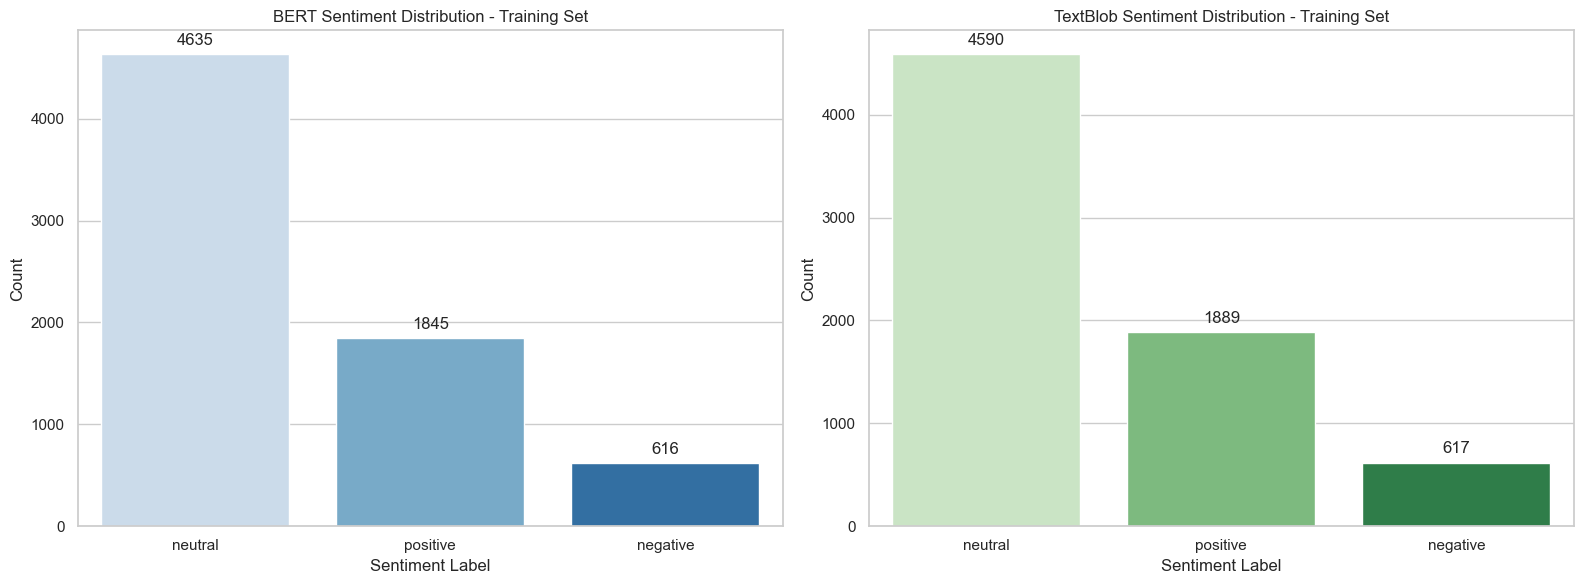


BERT Label Counts:
BERT_Predicted_Sentiment
neutral     4635
positive    1845
negative     616
Name: count, dtype: int64

TextBlob Predicted Label Counts:
predicted_label
neutral     4590
positive    1889
negative     617
Name: count, dtype: int64


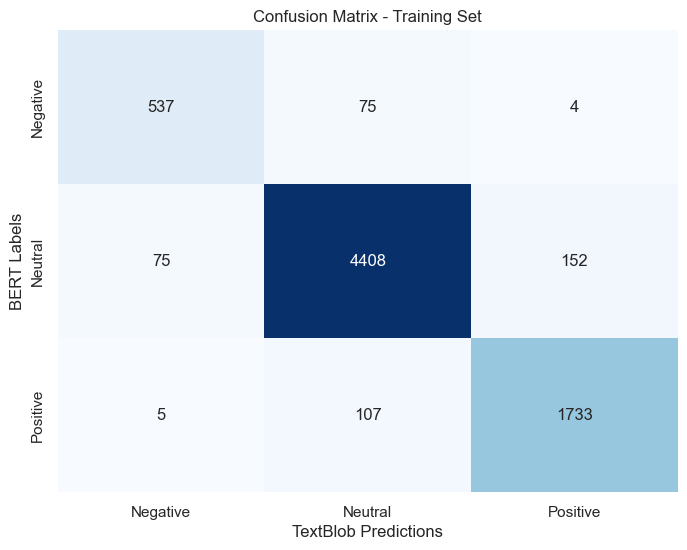


Confusion Matrix:
          Negative  Neutral  Positive
Negative       537       75         4
Neutral         75     4408       152
Positive         5      107      1733
Classification report saved to 'classification_report_textblob.json'

Classification Report:
                precision    recall    f1-score   support  
------------------------------------------------------------
Negative           0.87       0.87       0.87       616    
Neutral            0.96       0.95       0.96       4635   
Positive           0.92       0.94       0.93       1845   
------------------------------------------------------------
accuracy           0.94       nan        nan        7096   
macro avg          0.92       0.92       0.92       7096   
weighted avg       0.94       0.94       0.94       7096   

=== Test Set Analysis ===

Sentiment Distribution:


C:\Users\amirb\AppData\Local\Temp\ipykernel_16340\4023040814.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=true_counts.index, y=true_counts.values, palette="Blues", ax=ax1)
C:\Users\amirb\AppData\Local\Temp\ipykernel_16340\4023040814.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pred_counts.index, y=pred_counts.values, palette="Greens", ax=ax2)


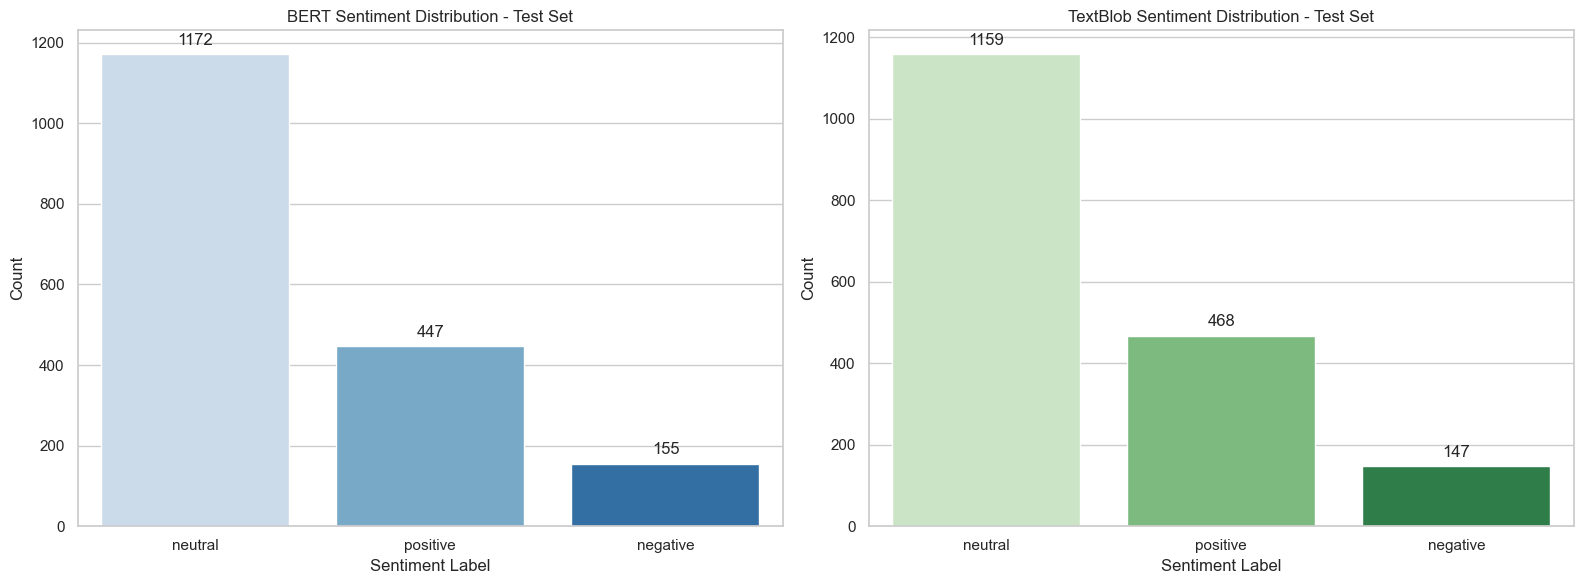


BERT Label Counts:
BERT_Predicted_Sentiment
neutral     1172
positive     447
negative     155
Name: count, dtype: int64

TextBlob Predicted Label Counts:
predicted_label
neutral     1159
positive     468
negative     147
Name: count, dtype: int64


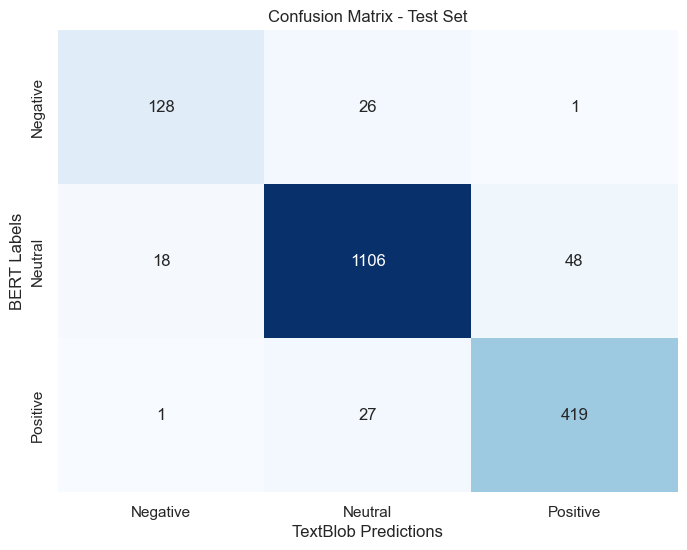


Confusion Matrix:
          Negative  Neutral  Positive
Negative       128       26         1
Neutral         18     1106        48
Positive         1       27       419
Classification report saved to 'classification_report_textblob.json'

Classification Report:
                precision    recall    f1-score   support  
------------------------------------------------------------
Negative           0.87       0.83       0.85       155    
Neutral            0.95       0.94       0.95       1172   
Positive           0.90       0.94       0.92       447    
------------------------------------------------------------
accuracy           0.93       nan        nan        1774   
macro avg          0.91       0.90       0.90       1774   
weighted avg       0.93       0.93       0.93       1774   

Saving results...
Results saved successfully to train_dataset_textblob.csv
Results saved successfully to test_dataset_textblob.csv

✅ Deployment assets saved to:
   - textblob_sentiment_model.p

In [6]:
if __name__ == "__main__":
    main()

combined_df = pd.concat(
    [
        pd.read_csv('train_dataset_textblob.csv'),
        pd.read_csv('test_dataset_textblob.csv')
    ],
    ignore_index=True
)
combined_df.to_csv('combined_textblob.csv', index=False)
print("✅ Combined sentiment dataset saved as 'combined_textblob.csv'")